# <center>Practical 03: Robot Control</center>

In [1]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import time
import scipy.linalg as linalg
import pickle

import sys
import os
sys.path.insert(0, os.path.abspath('Support'))

from Robot import Robot, Robot1D
from Helper import get_distance_robot_to_goal, get_angle_robot_to_goal, clamp_angle
from Renderer import Renderer as RobotRenderer2D
from Renderer1D import RobotRenderer as RobotRenderer1D

**See docstring for functions in support scripts**: If you want to know what a function does, just click somewhere within the parentheses that enclose the arguments and hit SHIFT+TAB. If there's a + button at the top of the popup tooltip, this means the documentation spans a few lines, click it to show the full docstring, then scroll up.

## 1. PID Control - 1D Linear System

Recall our 1D robot 

<img src="https://i.postimg.cc/k4M3B22Y/1DRobot.png" height="400" align="center">

We want to implement a controller that generates the signal $\mathbf{u}_t$ required to bring the robot to a desired state $\mathbf{x}_d$

We first define our robot in State-Space Form:

$\mathbf{x}_{t+1} = A\mathbf{x}_t + B\mathbf{u}_t \\$
$\mathbf{y}_{t} = C\mathbf{x}_t$,

where $A$ corresponds to the state matrix, $B$ defines the input or control matrix and $C$ corresponds to the output matrix. Our robot will be represented by the Python class ``Robot1D``

In [2]:
class Robot1D(object):

    """
    A simple implementation of a 1D robot in state-space form
    The constant MAX_CONTROL bounds the magnitude of the control signal that can be applied to the robot 
    """

    MAX_CONTROL = 500
    
    def __init__(self, A=np.eye(1), B=np.array([0]), C=np.array([0]), initial_state=np.array([10])):
        
        """
        Initialize a new model. 
        :param A: nxn state matrix, where n = state dimensionality
        :param B: nx1 input matrix, where n = state dimensionality
        :param C: 1xn input matrix, where n = state dimensionality
        :param initial_state: 2x1 vector with the initial state of our system
        """
        self.A = A
        self.B = B
        self.C = C
        self.state = initial_state
    
    def set_disturbance(self, value=0, start_time=None):
        """
        Set disturbance signal for the robot
        :param disturbance_value: Magnitude of the constant step disturbance
        :param start_time: Time at which disturbance should be applied (step disturbance at t > T)
        """
        self.disturbance = value
        self.disturbance_start_time = start_time
                
    def drive(self, control_u=10, current_time=None):
        """
        Update the system's state given a new control input
        :param control_u: Control input
        """
        # Make sure control signal is within -MAX_CONTROL < control_u < MAX_CONTROL
        clip_control = np.clip(control_u, -self.MAX_CONTROL, self.MAX_CONTROL)

        # Apply disturbance signal if current time is past disturbance start time
        d = 0
        if current_time is not None and self.disturbance_start_time is not None:
            if current_time >= self.disturbance_start_time:
                d = self.disturbance

        # update state
        state_t1 = self.A @ self.state + self.B * (clip_control + d)
        self.state = state_t1
            
    def get_state(self):
        """
        Get the system's current state
        """
        return self.state
    
    def get_output(self):
        """
        Get the system's ouput (position of the robot along the 1D line)
        """
        return np.array(self.C @ self.state)
                
    def get_error(self, desired_x):
        """
        This method measures the error (scalar) between the current robot's state and the desired state
        :param desired_x: Desired state (i.e., position) on the 1D line
        """
        return np.array(desired_x - self.state)

### Define our PID Controller

Let us now define our PID controller. Recall the formulation of a PID controller in the discrete domain:

$$\mathbf{u}_t = K_p \mathbf{e}_t + K_i \sum_{k = 0}^t \mathbf{e}_k \Delta t + K_d \frac{\mathbf{e}_t - \mathbf{e}_{t-1}}{\Delta t}$$

- $K_p, K_i, K_d$ are the proportional, integral and derivative gains
- $\mathbf{e}_t$ is the error at time $t$. In our case $\mathbf{e}_t = \mathbf{x}_d - \mathbf{x}_t$
- $\Delta t$ is the rate at which the PID controller is updated

In [4]:
class PID(object):
    
    """A simple PID controller."""

    def __init__(self, system=None, desired_state=None, K_p=0, K_i=0, K_d=0, update_rate=0.05):
        
        """
        Initialize a new PID controller.
        :param system: The robot system to controlled
        :param desired_state: The goal state that the PID will try to achieve for the robotic system
        :param K_p: The value for the proportional gain K_p
        :param K_i: The value for the integral gain K_i
        :param K_d: The value for the derivative gain K_d
        :param update_rate: Rate at which the PID controller is updated. 
        """
        self.system = system
        self.set_point = desired_state
        self.K_p = K_p
        self.K_i = K_i
        self.K_d = K_d
        self.update_rate = update_rate
        
        # Last observed error between desired state (self.set_point) and the current state of the system
        self.last_error = self.system.get_error(self.set_point)
        
        # Accumulator for integral term
        self.integral = 0
        
        # Last time the controller was called
        self.last_time = 0
        
        # Last control command provided to the system
        self.last_control = 0
        
    def compute_control(self):
        
        """
        This method computes the next control signal u_t so as to reduce the error
        between the robot's current state and the desired state (self.set_point)
        """
        
        delta_time = self.update_rate
        
        # Compute error
        error_t = self.system.get_error(self.set_point)
        
        # Compute integral and derivative terms
        derivative = (error_t - self.last_error) / delta_time
        self.integral += error_t * delta_time
        
        # Compute new control
        new_control = self.K_p * error_t + self.K_i * self.integral + self.K_d * derivative
        
        # Update self.last_error, self.last_time and self.last_control signal with new values
        self.last_error = error_t
        self.last_time += self.update_rate
        self.last_control = new_control
                
        return new_control

### Test the Controller

Let us now test our controller. We consider the following values in our current test case:
- The robot initial state is $\mathbf{x}_0 = (10, 0)$. The desired states is $\mathbf{x}_d = (50, 0)$
- The PID gains are set to $K_p=0.2, K_i=0, K_d=0.001$
- Our control loop runs for 50 frames (controlled by the variable total_frames) with $dt=0.01$ (controlled by the variable update_rate)


In [27]:
# Tasks we can set the students
# Run it with no disturbance, and P=0.2, I=0
# Run it with disturbance (d=-2 @ t=0.2), and P=0.2, I=0
# Run it with disturbance (d=-2 @ t=0.2), and P=0.2, I=0.5

# Define state, input and output matrices
#A = np.array([[1, 0], [1, 0]]) # 2D robot but only has control in the x-axis
#B = np.array([[0.5],[0]])
#C = np.array([1, 0])
A=np.array([1])
B=np.array([0.5])
C=np.array([1])

# Define disturbance if any. Default is no disturbance: value=0, start_time=None
disturbance_value = 0
disturbance_start_time = 0.2

# Create a robot and define desired state
#initial_state = np.array([[10],[0]])
initial_state = np.array([10])
bot = Robot1D(A=A, B=B, C=C, initial_state=initial_state)
bot.set_disturbance(disturbance_value, disturbance_start_time)
#desired_x = np.array([[50],[0]]) # default value is 50
desired_x = np.array([50])

# Visualization parameters
#u, sim_time, error, robot_state = np.array([[0],[0]]), np.array([0]), bot.get_error(desired_x), bot.get_output()
u, sim_time, error, robot_state = np.array([0]), np.array([0]), bot.get_error(desired_x), bot.get_output()
total_frames = 300 # default value is 50
update_rate = 0.01

# Create a PID controller
pid = PID(system=bot, desired_state=desired_x, K_p=0.2, K_i=0.0, K_d=0.001, update_rate=update_rate) # Default value is Kp=0.2, Ki=0

# This is our control loop. Currently we call our controller for 0.5 second
for curr_frame in range(1, total_frames, 1):
    
    # Call controller to get new signal u_t
    u_t = pid.compute_control()
    # print(u_t)
    
    # Apply control to robot
    bot.drive(u_t, current_time=sim_time[-1])

    # Save values for plotting
    sim_time = np.hstack( (sim_time, update_rate*int(curr_frame)))
    error = np.hstack((error, bot.get_error(desired_x)))
    u = np.hstack((u, u_t))
    robot_state = np.hstack((robot_state, bot.get_output()))

### Visualise the Resulting Trajectories

Let us now plot the changes observed in error (right-bottom), control signal (right-top), and robot's state (left) 

Box(children=(IntSlider(value=0, description='Frame: ', layout=Layout(flex='3 1 0%', width='auto'), max=299), …

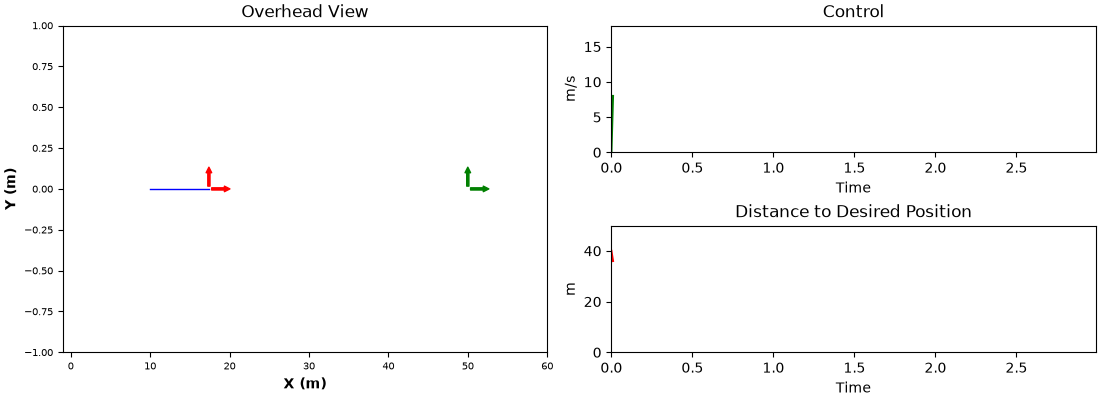

In [28]:
# Define renderer and start animation
rend = RobotRenderer1D.Instance()
rend.initialize(robot_state, u, error, sim_time, desired_x, dt_render=update_rate)

### Add a disturbance, and integral control

Repeat the test above
- Set disturbance_value=-0.2
- Set disturbance_value=-0.2, K_p=0.2, K_i=0.5

## 2. PID Control - Differential Drive Vehicle

Recall the kinematic model of our PenguinPi robot:

<img src="https://i.postimg.cc/NMNhTQTs/Penguin-Pi-Model.png" width="400" align="center">

In this model, the state is defined by a 3D vector ($x, y, \theta)$ and the control input corresponds to the linear and angular velocities $(v, \omega)$.

### Define a Move to Goal Controller

Consider the problem of moving a diff drive robot to a goal point $(x_g, y_g)$. How can we solve this control problem?

Let us define 2 proportional controllers:
- One controller with gain $K_{pw}$ that will turn the robot toward the goal. This controller determines the angular velocity $\omega_k$ according to

$$\omega_k = K_{pw} (\theta_g - \theta_r)$$

where $\theta_g$ corresponds to the angle to the goal relative to the heading of the robot and $\theta_r$ is the heading of the robot at time $k$.

- One controller with gain $K_{pv}$ that will keep moving the robot forward until it reaches the goal. This controller determines the linear velocity $v_k$ according to

$$v_k = K_{pv}\sqrt{(y_g-y_k)^2+(x_g-x_k)^2}$$

We have combined these 2 controllers into a single class called ``MoveToGoalController``. Two helper functions ``get_distance_robot_to_goal(.)`` and ``get_angle_robot_to_goal(.)`` have been defined to compute $(\theta_g - \theta_r)$ and $\sqrt{(y_g-y_k)^2+(x_g-x_k)^2}$ respectively.


#### TODO: 
- Compute both $\omega_k$ and $v_k$

In [17]:
class PIDController():
    def __init__(self, K_p=0, K_i=0, K_d=0, update_rate=0.01):
        self.K_p = K_p
        self.K_i = K_i
        self.K_d = K_d
        self.update_rate = update_rate
        
        # Last observed error
        self.last_error = 0
        
        # Accumulator for integral term
        self.integral = 0
        
    def compute_control(self, error):
        """
        Compute the control signal based on error
        :param error: Current error
        :return: Control signal
        """
        
        delta_time = self.update_rate
        
        # Compute integral and derivative terms
        derivative = (error - self.last_error) / delta_time
        self.integral += error * delta_time
        
        # Compute control signal
        control = self.K_p * error + self.K_i * self.integral + self.K_d * derivative
        
        # Update last error
        self.last_error = error
        
        return control


class MoveToGoalController(object):
    """A simple move to goal proportional controller"""

    def __init__(self, robot=None, K_pw=0, K_iw=0, K_dw=0, K_pv=0, K_iv=0, K_dv=0):
        """
        Initialize a new move to goal proportional controller
        :param robot: The robotic system to controlled
        :param K_w: The proportional gain for the angular velocity
        :param K_v: The proportional gain for the linear velocity
        """
        self.robot = robot

        # Create PID controller for linear velocity
        self.pid_v = PIDController(K_p=K_pv, K_i=K_iv, K_d=K_dv)
        
        # Create PID controller for angular velocity
        self.pid_w = PIDController(K_p=K_pw, K_i=K_iw, K_d=K_dw)
        
        
    def run(self, goal_position=np.zeros(2), threshold=0.1, delta_time=0.01, max_sim_time=5): #default for max_sim_time is 3
        """
        Run control loop until the robot reaches the goal_position
        :param goal_position: Desired goal position
        :param threshold: Value used to determine whether robot has reached the goal location
        """
        states = []
        controls = []
        initial_state = self.robot.get_state()
        self.pid_v.update_rate = delta_time
        self.pid_w.update_rate = delta_time
        
        distance_to_goal = get_distance_robot_to_goal(initial_state, goal_position)
        desired_heading = get_angle_robot_to_goal(initial_state, goal_position)
                
        states.append(initial_state)
        current_time = 0
        
        while distance_to_goal > threshold:
            
            #TODO: Compute control input -----------------------------------------------------

            v_k = self.pid_v.compute_control(distance_to_goal)
            w_k = self.pid_w.compute_control(desired_heading)
          
            #ENDTODO --------------------------------------------------------------------------
            
            # Apply control to robot
            self.robot.drive(v_k, w_k, delta_time, current_time)
            new_state = self.robot.get_state()
            
            # Keep track of variables for plotting
            controls.append([v_k, w_k])
            states.append(new_state)
                        
            # Update distance and desired heading (error)
            distance_to_goal = get_distance_robot_to_goal(new_state, goal_position)
            desired_heading = get_angle_robot_to_goal(new_state, goal_position)

            # Increment time
            current_time += delta_time
            if current_time >= max_sim_time: break
                       
        return states, controls

### Test the Controller

Let us now visualise how our robot moves toward a goal position using the control signals computed by our ``MoveToGoalController``

We consider the following values in our current test case:
- The robot initial state is $\mathbf{x}_0 = (-1.5, -1.5, \frac{\pi}{3})$. The desired states is $\mathbf{x}_d = (1.0, 1.0)$.
- The proportional gains are set to $K_{pw}=5, K_{pv}=2$
- Our control loop runs until $\sqrt{(y_g-y_k)^2+(x_g-x_k)^2} > 0.01$

Box(children=(IntSlider(value=0, description='Frame: ', layout=Layout(flex='3 1 0%', width='auto'), max=501), …

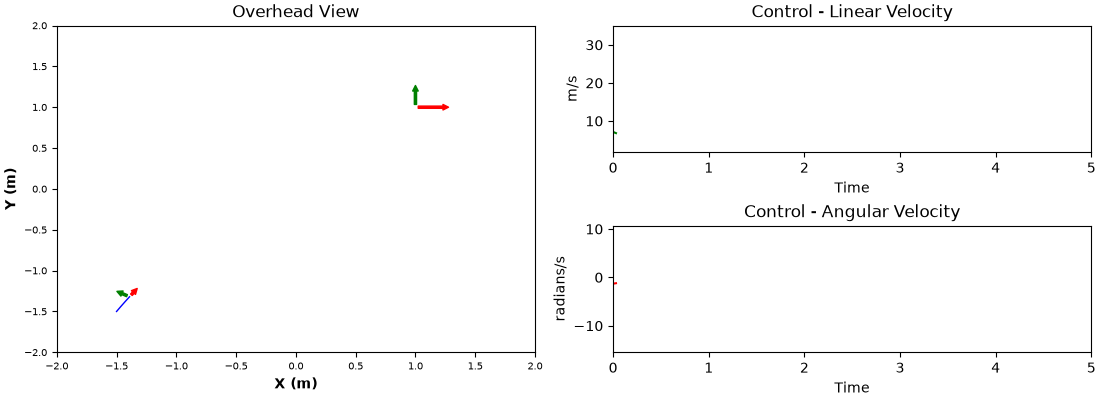

In [21]:
# Define robot, desired goal and delta time
bot = Robot(init_state=np.array([-1.5, -1.5, np.pi/3]))
desired_goal = np.array([1.0, 1.0]) # target x, target y
delta_t = 0.01
max_sim_time=5

# Define disturbance. Default is none: all 0, and start_time=None
d_theta_value = 0.0
d_x_value = 0.02
d_y_value = 0.0
disturbance_start_time = 0.5
bot.set_disturbance(d_theta=d_theta_value, d_x=d_x_value, d_y=d_y_value, start_time=disturbance_start_time)

# Instantiate controller and compute sequence of control signals
controller = MoveToGoalController(bot, K_pw=5, K_iw=2, K_dw=0.0, K_pv=2, K_iv=1, K_dv=0.0)
# Default K_pw=5, K_iw=0.0, K_dw=1, K_pv=2, K_iv=1, K_dv=0.0
robot_states, robot_controls = controller.run(goal_position=desired_goal, threshold=0.01, delta_time=delta_t, max_sim_time=max_sim_time) 
# Define variables for animation
array_states = np.array(robot_states)
array_controls = np.array(robot_controls)

# Define renderer and start animation
rend = RobotRenderer2D.Instance()
rend.initialize(array_states, array_controls, target_pose=desired_goal, dt_data=delta_t, max_sim_time=max_sim_time)

## 3. LQR - Discrete Time Infinite Horizon

Given a linear system with equations:

\begin{align*}
\mathbf{x}_{t+1} &= A\mathbf{x}_t + B\mathbf{u}_t \\
\mathbf{y}_{t} &= C\mathbf{x}_t,
\end{align*}

where $A$ corresponds to the state matrix, $B$ defines the input or control matrix and $C$ corresponds to the output matrix.

We wan to find $\mathbf{u}$ so as to minimize the cost function

$J = \sum_{t=0}^{\infty} ((\mathbf{x}_t-\mathbf{x}_g)^TQ(\mathbf{x}_t-\mathbf{x}_g) + \mathbf{u}_t^TR\mathbf{u})$,

where $Q$ defines the state cost and $R$ corresponds to the control cost.

To do so, we want to implement a **LQR Infinite Horizon Controller** with gain  
$K = (R+B^TPB)^{-1}(B^TPA)$

**TODO:**
- Complete the definition of the controller's gain K. You can use the function ``linalg.inv(.)`` to compute the inverse of a matrix
- Keep in mind that $P$ is defined by the class attribute ``self.P``

In [23]:
class DiscreteInfiniteLQR(object):
    
    """A simple LQR Infinite Horizon controller."""

    def __init__(self, Q=np.eye(1), R=0.3):
        
        """
        Initialize a new LQR controller.
        :param Q: State cost
        :param R: Control cost
        """
        
        self.Q = Q
        self.R = R
        
        # Controller gain to be defined once LQR function is solved
        self.K = np.zeros(1)
        self.P = np.eye(1)
                
    def solve(self, system):
        """
        Compute controller gain for a given system
        :param system: Linear system for which a control law needs to be
                       computed
        """
        A = system.A
        B = system.B
        
        # Solve Riccati Equation for P
        self.P = linalg.solve_discrete_are(A, B, self.Q, self.R)
        print(self.P)
                
        #TODO: Compute the controller's gain ----------------------------------------------
        self.K = linalg.inv(self.R + B.T @ self.P @ B) @ (B.T @ self.P @ A)
        
        #ENDTODO --------------------------------------------------------------------------
        
    def get_gain(self):
        """
        Get access to controller gain
        """
        return self.K

### Test the Controller

Let us now take a look at the state and control trajectories that can obtained using our LQR implementation. Keep in mind that the optimal controller is defined as

$\mathbf{u_t} = -K(\mathbf{x_t} - \mathbf{x_g})$,

where $\mathbf{x_g}$ corresponds to the desired state.

We consider the same test case used with our PID controller:
- The robot initial state is $\mathbf{x}_0 = (10, 0)$. The desired states is $\mathbf{x}_d = (50, 0)$
- Our control loop for 25 time steps with the update rate defined by the variable update_rate

In [24]:
# Create an instance of our 1D robot system
A = np.array([[1]])
B = np.array([[0.5]])
C = np.array([[1]])

bot = Robot1D(A=A, B=B, C=C, initial_state=np.array([[10]]))

# Define the state and control costs
Q = np.array([[5]])
R = 20

# Create an instace of our controller and solve the LQR problem
lqr = DiscreteInfiniteLQR(Q=Q, R=R)
lqr.solve(bot)

# Define desired state
desired_x = np.array([[50]])

# Visualization parameters
u_list, sim_time = np.array([[0]]), 0

error = bot.get_error(desired_x)
y_list = bot.get_output()
update_rate = 0.01
total_frames = 25

# This is our control loop. 
for curr_frame in range(1, total_frames, 1):
    
    # Get current state of the system
    x_t = bot.get_state()
    # Get output 
    y_t = bot.get_output()
    
    # Determine and apply control
    u_t = np.array(-lqr.K @ (x_t - desired_x))
    bot.drive(u_t)
    
    # Keep track of variable for plotting
    sim_time = np.hstack( (sim_time, update_rate*curr_frame))
    u_list =np.hstack((u_list, u_t))
    y_list = np.hstack((y_list,y_t)) 
    error = np.hstack((error, bot.get_error(desired_x)))

[[22.65564437]]


### Visualise the Resulting Trajectories

Let us now plot the changes observed in error (right-bottom), control signal (right-top), and robot's state (left) 

Box(children=(IntSlider(value=0, description='Frame: ', layout=Layout(flex='3 1 0%', width='auto'), max=24), B…

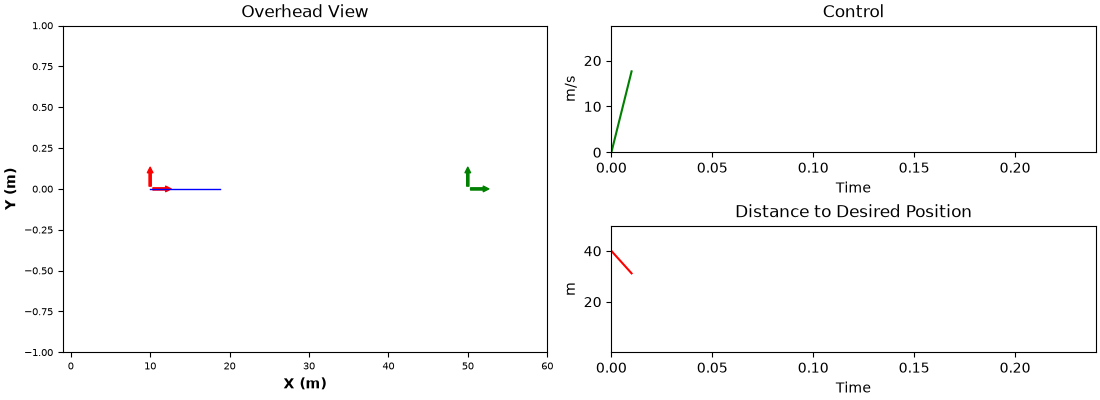

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (11,) and arg 1 with shape (25,).

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (20,) and arg 1 with shape (25,).

In [25]:
# Define renderer and start animation
rend = RobotRenderer1D.Instance()
rend.initialize(y_list.squeeze(), u_list.squeeze(), error.squeeze(), sim_time, desired_x, dt_render=update_rate)

### Interested in ILQR

Check out this repo: https://github.com/mgb45/ilqr_pendulum
